In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
scaler = StandardScaler()

In [ ]:
df = pd.read_csv("data.csv")
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [ ]:
df = df.drop(["id", "Unnamed: 32"], axis=1)
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [ ]:
df.isna().sum()

,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0
symmetry_mean,0


In [ ]:
df['diagnosis_bin'] = df['diagnosis'].map({'M': 1, 'B': 0})
X = df.drop(['diagnosis', 'diagnosis_bin'], axis=1)
Y = df['diagnosis_bin']

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
X_train_full = scaler.fit_transform(X_train)
X_test_full = scaler.transform(X_test)

In [ ]:
knn = KNeighborsClassifier()

In [ ]:
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier())
])

In [ ]:
param_grid = {
    "knn__n_neighbors": list(range(1, 31)),
    "knn__weights": ["uniform", "distance"],
    "knn__metric": ["euclidean", "manhattan"]
}

In [ ]:
cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)
grid = GridSearchCV(pipe, param_grid=param_grid, cv=cv, scoring='accuracy', n_jobs=-1)

In [ ]:
grid.fit(X_train, Y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=4, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('knn', KNeighborsClassifier())]),
             n_jobs=-1,
             param_grid={'knn__metric': ['euclidean', 'manhattan'],
                         'knn__n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11,
                                              12, 13, 14, 15, 16, 17, 18, 19,
                                              20, 21, 22, 23, 24, 25, 26, 27,
                                              28, 29, 30],
                         'knn__weights': ['uniform', 'distance']},
             scoring='accuracy')

In [ ]:
print(f"Best parameters found: {grid.best_params_}")
print(f"Best cross-validation accuracy: {grid.best_score_:.4f}")

Best parameters found: {'knn__metric': 'manhattan', 'knn__n_neighbors': 3, 'knn__weights': 'uniform'}
Best cross-validation accuracy: 0.9670


In [ ]:
best = grid.best_estimator_

In [ ]:
Y_pred = best.predict(X_test)
Y_proba = best.predict_proba(X_test)[:,1]
baseline_f1 = f1_score(Y_test, Y_pred)
baseline_accuracy = accuracy_score(Y_test, Y_pred)
baseline_auc = roc_auc_score(Y_test, Y_proba)
print("Baseline f1:", baseline_f1)
print("Baseline accuracy:", baseline_accuracy)
print("Baseline AUC:", baseline_auc)

Baseline f1: 0.9534883720930233
Baseline accuracy: 0.9649122807017544
Baseline AUC: 0.9841139862430397


In [ ]:
results = []

In [ ]:
X_ablation = X_train.copy()

In [ ]:
for col in X_ablation.columns:

  X_train_reduced = X_train.drop(columns=[col])
  X_test_reduced = X_test.drop(columns=[col])

  knn_ab = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(metric = 'manhattan', n_neighbors = 3, weights = 'uniform'))
    ])

  knn_ab.fit(X_train_reduced, Y_train)

  Y_pred = knn_ab.predict(X_test_reduced)
  Y_proba = knn_ab.predict_proba(X_test_reduced)[:, 1]

  f1 = f1_score(Y_test, Y_pred)
  accuracy = accuracy_score(Y_test, Y_pred)
  auc = roc_auc_score(Y_test, Y_proba)

  results.append((col, f1, accuracy, auc))

In [ ]:
results

[('radius_mean',
  0.9411764705882353,
  0.956140350877193,
  np.float64(0.9832951195545364)),
 ('texture_mean',
  0.9545454545454546,
  0.9649122807017544,
  np.float64(0.9849328529315428)),
 ('perimeter_mean',
  0.9534883720930233,
  0.9649122807017544,
  np.float64(0.9847690795938421)),
 ('area_mean',
  0.9534883720930233,
  0.9649122807017544,
  np.float64(0.9844415329184408)),
 ('smoothness_mean',
  0.9425287356321839,
  0.956140350877193,
  np.float64(0.9767441860465115)),
 ('compactness_mean',
  0.9534883720930233,
  0.9649122807017544,
  np.float64(0.9841139862430397)),
 ('concavity_mean',
  0.9534883720930233,
  0.9649122807017544,
  np.float64(0.9847690795938421)),
 ('concave points_mean',
  0.9534883720930233,
  0.9649122807017544,
  np.float64(0.9847690795938421)),
 ('symmetry_mean',
  0.9534883720930233,
  0.9649122807017544,
  np.float64(0.973141172617098)),
 ('fractal_dimension_mean',
  0.9534883720930233,
  0.9649122807017544,
  np.float64(0.9850966262692433)),
 ('radiu

In [ ]:
ablation_df = pd.DataFrame(results, columns=["feature", "f1", "accuracy", "auc"])

In [ ]:
metrics = ["f1", "accuracy", "auc"]
baselines = {
    "f1": baseline_f1,
    "accuracy": baseline_accuracy,
    "auc": baseline_auc
}

In [ ]:
ablation_df["delta_f1"] = baseline_f1 - ablation_df["f1"]
ablation_df["delta_accuracy"] = baseline_accuracy - ablation_df["accuracy"]
ablation_df["delta_auc"] = baseline_auc - ablation_df["auc"]

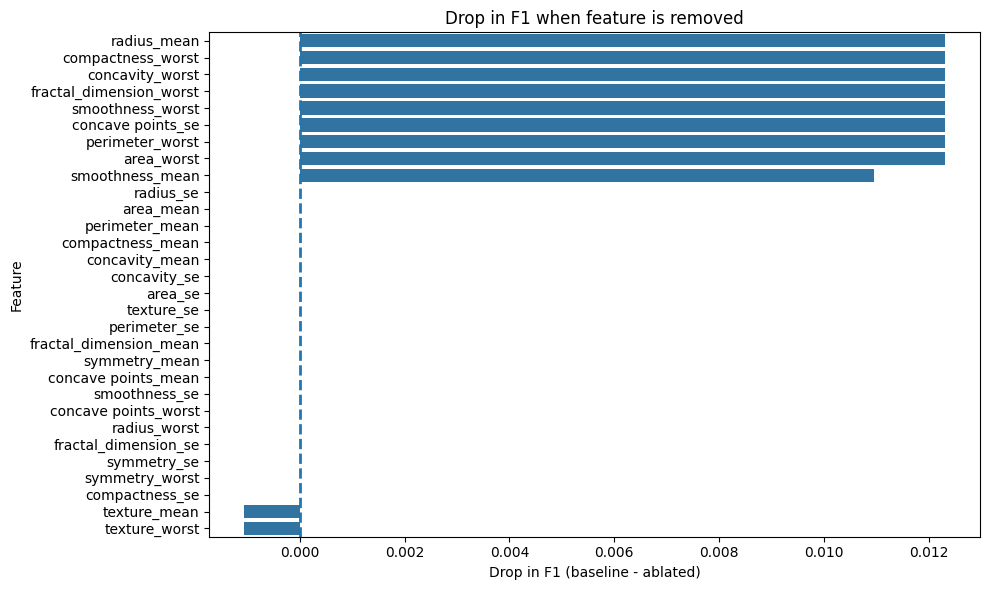

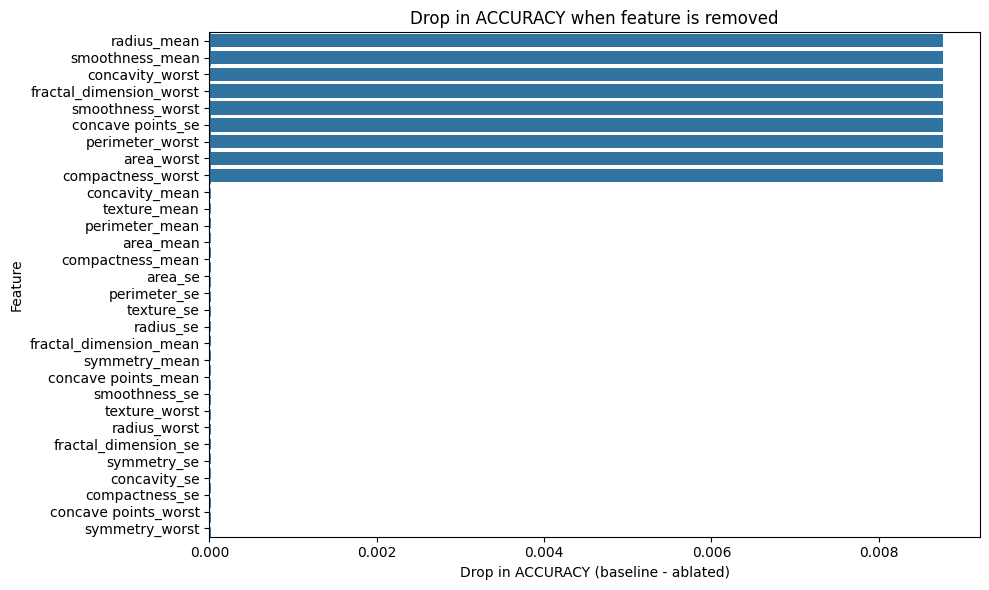

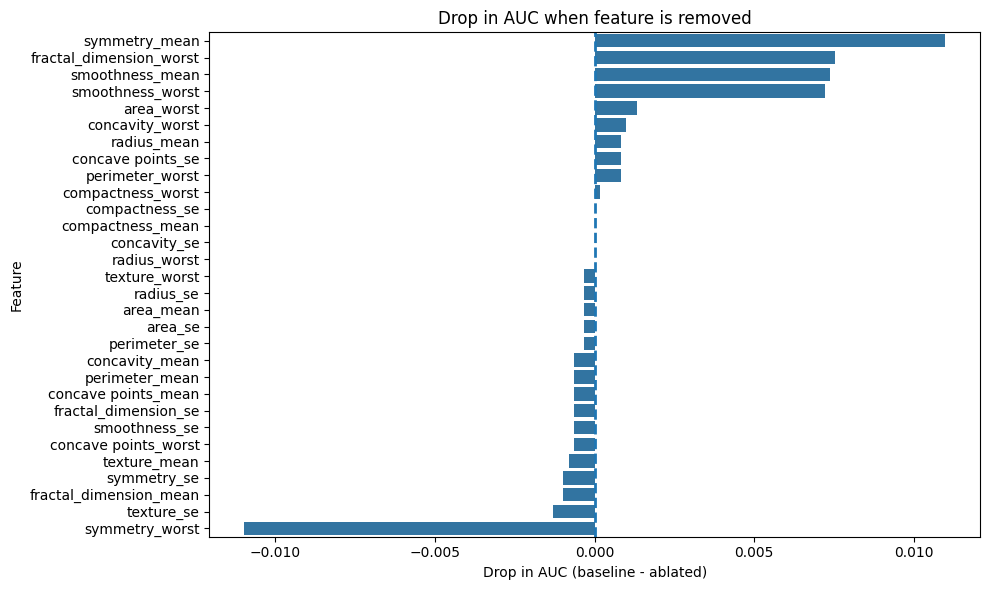

In [ ]:
for metric in metrics:
    delta_col = f"delta_{metric}"

    plot_df = ablation_df.sort_values(delta_col, ascending=False)

    plt.figure(figsize=(10, 6))
    sns.barplot(data=plot_df, x=delta_col, y="feature")

    plt.axvline(0, linestyle="--", linewidth=2)

    plt.title(f"Drop in {metric.upper()} when feature is removed")
    plt.xlabel(f"Drop in {metric.upper()} (baseline - ablated)")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

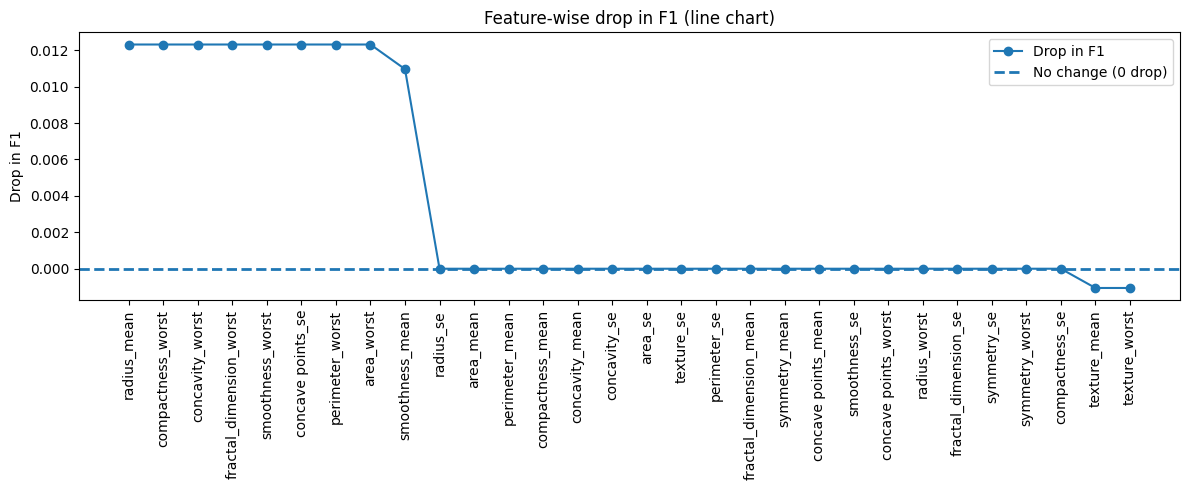

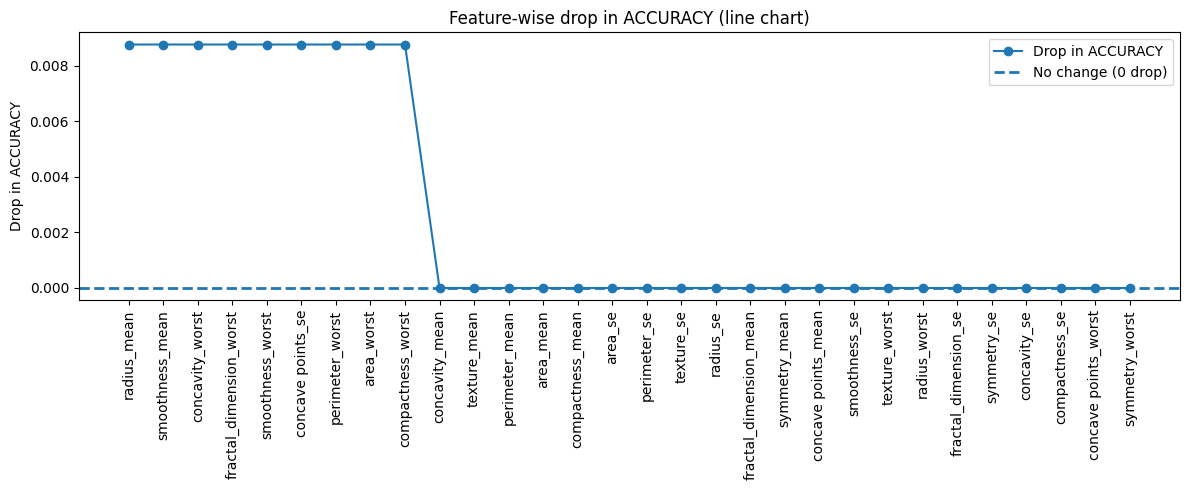

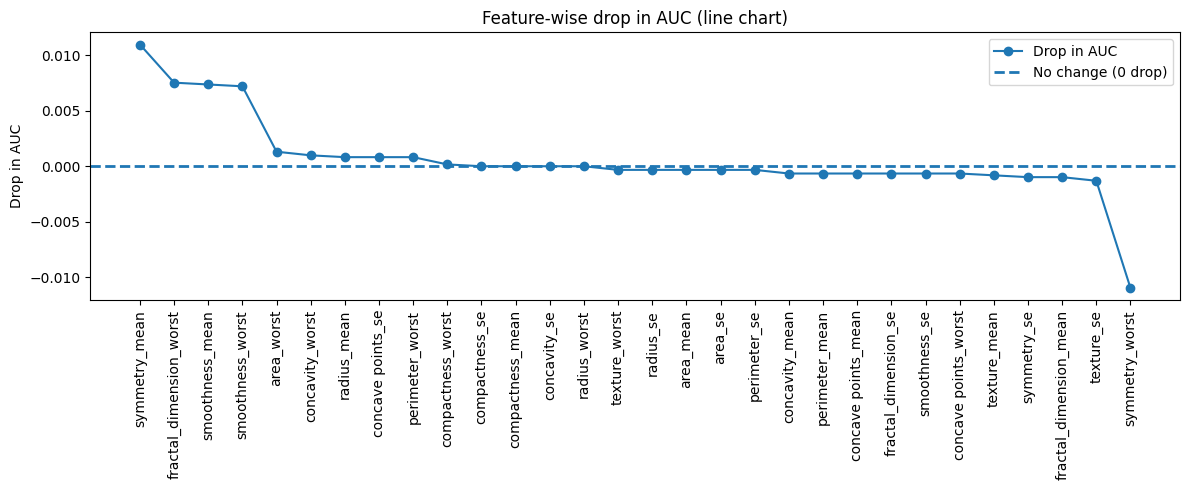

In [ ]:
for metric in metrics:
    delta_col = f"delta_{metric}"
    plot_df = ablation_df.sort_values(delta_col, ascending=False).reset_index(drop=True)

    plt.figure(figsize=(12, 5))
    plt.plot(plot_df.index, plot_df[delta_col], marker="o", label=f"Drop in {metric.upper()}")

    plt.axhline(0, linestyle="--", linewidth=2, label="No change (0 drop)")

    plt.xticks(plot_df.index, plot_df["feature"], rotation=90)
    plt.ylabel(f"Drop in {metric.upper()}")
    plt.title(f"Feature-wise drop in {metric.upper()} (line chart)")
    plt.legend()
    plt.tight_layout()
    plt.show()


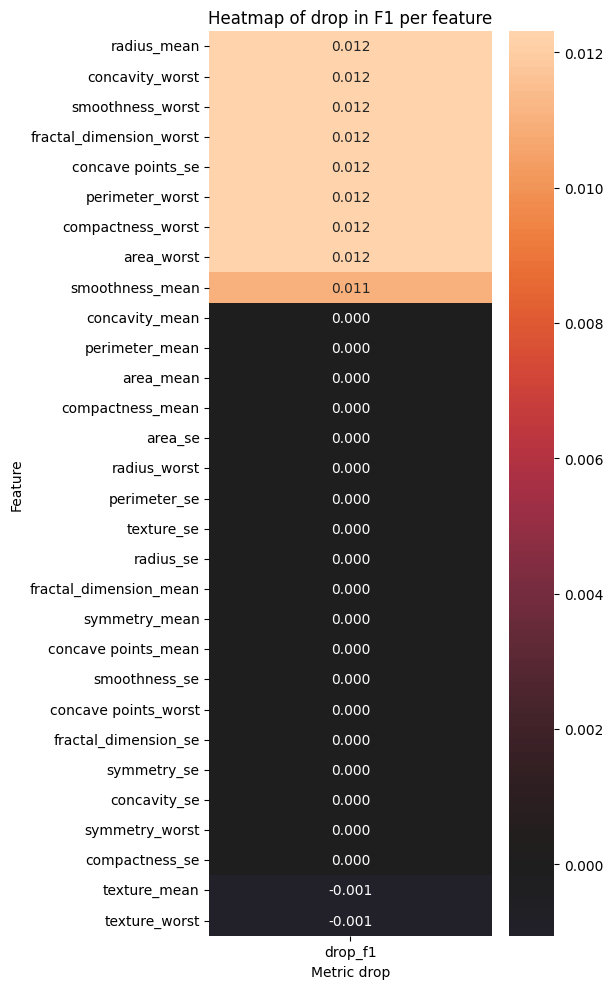

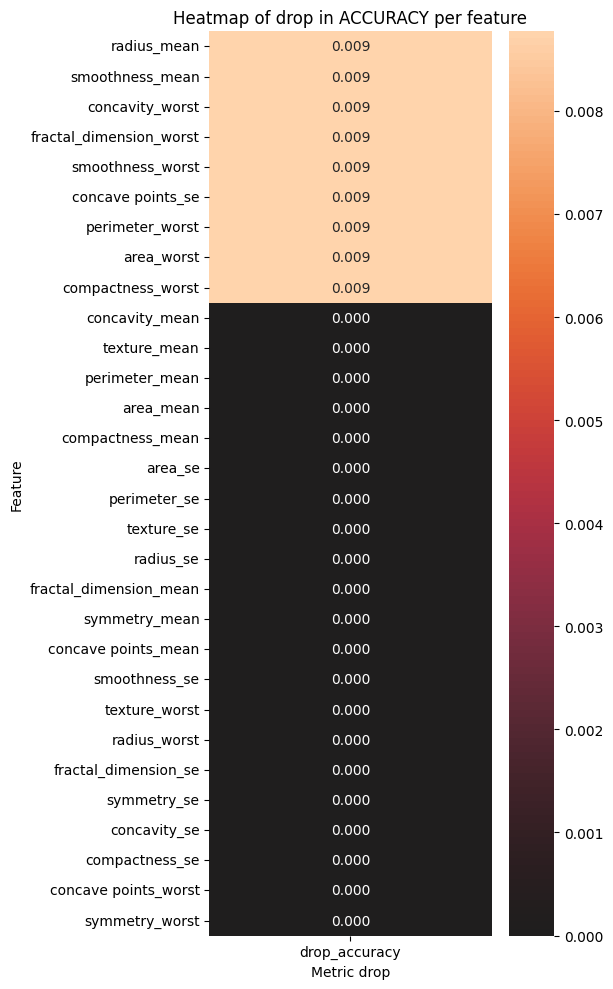

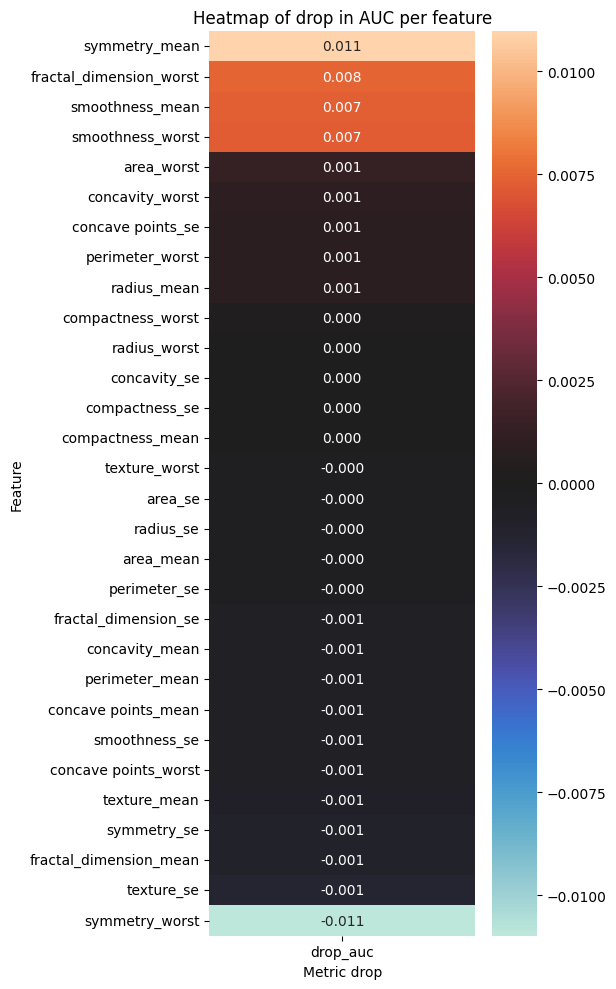

In [ ]:
for metric in metrics:
    delta_col = f"delta_{metric}"
    plot_df = ablation_df.sort_values(delta_col, ascending=False)

    heat_data = plot_df[[delta_col]].set_index(plot_df["feature"])
    heat_data.columns = [f"drop_{metric}"]

    plt.figure(figsize=(6, 10))
    sns.heatmap(heat_data, annot=True, fmt=".3f", center=0)
    plt.title(f"Heatmap of drop in {metric.upper()} per feature")
    plt.xlabel("Metric drop")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()


## Features whose removal improved the model (suggesting they might be less important or noisy):

  - smoothness_mean and symmetry_se: Removing these features led to the most significant positive changes in both accuracy (up to +0.0175) and F1-score (up to +0.0233).
  - fractal_dimension_worst: Its removal resulted in the highest positive change in ROC AUC (+0.0093).


## Features whose removal degraded the model (suggesting they are important):

  - concavity_mean: This feature showed the most negative impact on ROC AUC when removed (-0.00147).

  - Other features like radius_mean, perimeter_mean, area_mean, concave points_mean, radius_se, area_worst, and concavity_worst showed no change in accuracy or F1-score upon removal but minor negative changes in ROC AUC. This indicates a subtle but positive contribution to the model's overall performance.